In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import cartopy as cr # for geographic mapping
import cartopy.crs as ccrs # for map projections
import matplotlib.pyplot as plt # plotting tool
import matplotlib
import seaborn as sns
import cartopy.feature as cfeature # to add coastlines, land and ocean
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cmocean
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as mticker
import xskillscore as xs
import os
import glob
import matplotlib.patches as patches
from scipy.stats import norm, normaltest, shapiro
from scipy.stats import t as t_fun
from eofs.xarray import Eof
plt.rcParams["font.family"] = "Times New Roman"
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
from datetime import datetime
from scipy import signal

In [17]:
def lowpass(b,t):
    import xrscipy.signal as dsp
    a=b.copy()
    tim=a.time
    a['time']=np.arange(len(a['time']))
    ff=dsp.filters.lowpass(a, 1/t, order=5,dim='time')
    ff['time']=tim
    a['time']=tim
    return ff

def ren_fun_sck(dc,decode=False):
    if decode == False:
        ds=xr.open_dataset(dc)
    else:
        ds=xr.open_dataset(dc,decode_times=False)
    for i in list(ds.coords.keys()):
        if ds[i].attrs['axis']=='X':
            ds=ds.rename({i:'lon'})
        elif ds[i].attrs['axis']=='Y':
            ds=ds.rename({i:'lat'})
        elif ds[i].attrs['axis']=='Z':
            ds=ds.rename({i:'depth'})
        else :
            ds=ds.rename({i:'time'})
    return ds
    
def find_path(directory, extension):
    if not extension.startswith('.'):
        extension = '.' + extension
    search_pattern = os.path.join(directory, '*' + extension)
    files_with_extension = glob.glob(search_pattern)   
    return files_with_extension


def fig_beauty(ax,n,m,c,xx,cs=0.5,lc='grey'):
    '''
       sets the aesthetics of the figure
       parameter :
       ============
       ax : axis

       n,m : number of rows and columns

       c   : iterator

       xx  : label size

       cs  : cost line width
       ocean: boolean
              whether to add ocean 
    '''
    ax.add_feature(cfeature.LAND,alpha=1,color=lc,zorder=1)
    ax.add_feature(cfeature.COASTLINE,zorder=2,lw=cs)
    ax.set_ylabel('')
    ax.set_yticklabels('')
    gl=ax.gridlines(color='black',linestyle='--',alpha=0.15,linewidth=0.5)
    gl.xlabel_style = {'size': xx, 'color': 'black'}
    gl.ylabel_style = {'size': xx, 'color': 'black'}
    aa=[]
    for x in range(n):
        for y in range(m):
            aa.append([x,y])
    indices=aa[c]

    if indices[0] == n-1:
    	gl.bottom_labels=True
    if indices[1] == 0:
    	gl.left_labels = True
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER



from scipy.signal import butter, sosfilt, sosfiltfilt
def butter_bandpass_sos(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')
    return sos

def butter_lowpass_filter_sos(data, axis, cutoff, fs, order=5, filtopt='acausal'):
    sos = butter_lowpass_sos(cutoff, fs, order=order)
    if filtopt == 'causal':
        y = lfilter(b, a, data, axis)
    else:
        y = sosfiltfilt(sos, data, axis=axis)
    return y

def butter_bandpass_filter_sos(data, axis, lowcut, highcut, fs, order=8, filtopt='acausal'):
    sos = butter_bandpass_sos(lowcut, highcut, fs, order=order)
    if filtopt == 'causal':
        y = lfilter(b, a, data, axis)
    else:
        y = sosfiltfilt(sos, data, axis=axis)
    return y



def cor(lat):
    Omega = 7.292e-5 
    phi = np.deg2rad(lat)
    f = 2 * Omega * np.sin(phi)
    T = 2 * np.pi / f     # seconds
    T_hours = T / 3600    # hours
    return T_hours


def ke_comps(u,v,lat):
    thour = cor(lat)
    KE= KinEn(u,v)

    u_bp = butter_bandpass_filter_sos(
    u,
    axis=0,
    lowcut=1/(thour*1.2),
    highcut=1/(thour*0.8),
    fs=1/6,
    order=8,
    filtopt='acausal')

    v_bp = butter_bandpass_filter_sos(
    v,
    axis=0,
    lowcut=1/(thour*1.2),
    highcut=1/(thour*0.8),
    fs=1/6,
    order=8,
    filtopt='acausal')
    KE_bp = KinEn(u_bp,v_bp)

    KE_bp = xr.DataArray(KE_bp,coords={'time':KE.time})
    return KE,KE_bp

def inertial_filter(u,v,lat):
    thour = cor(lat)

    u_bp = butter_bandpass_filter_sos(
    u,
    axis=0,
    lowcut=1/(thour*1.2),
    highcut=1/(thour*0.8),
    fs=1/6,
    order=8,
    filtopt='acausal')

    v_bp = butter_bandpass_filter_sos(
    v,
    axis=0,
    lowcut=1/(thour*1.2),
    highcut=1/(thour*0.8),
    fs=1/6,
    order=8,
    filtopt='acausal')
    u_bp=xr.DataArray(u_bp,coords=u.coords)

    return xr.DataArray(u_bp,coords=u.coords),xr.DataArray(v_bp,coords=v.coords)

import xarray as xr

def butter_lowpass_sos(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq

    sos = butter(
        order,
        normal_cutoff,
        btype='low',
        analog=False,
        output='sos'
    )

    return sos

def lowpass_background_filter(u, v, lat):
    thour = cor(lat)   # inertial period in hours

    cutoff = 1 / (thour*0.8)   

    u_lp = butter_lowpass_filter_sos(
        u,
        axis=0,
        cutoff=cutoff,
        fs=1/6,          # 6-hourly sampling
        order=8,
        filtopt='acausal'
    )

    v_lp = butter_lowpass_filter_sos(
        v,
        axis=0,
        cutoff=cutoff,
        fs=1/6,
        order=8,
        filtopt='acausal'
    )

    return (
        xr.DataArray(u_lp, coords=u.coords, dims=u.dims),
        xr.DataArray(v_lp, coords=v.coords, dims=v.dims)
    )

## Process NI-KE

In [18]:
uvels=[]
vvels=[]
dsu=ren_fun_sck('asani_83.nc')['UAVE']
dsv=ren_fun_sck('asani_83.nc')['VAVE']
for i in range(232):
    dsuu=dsu.isel(lat=i)
    dsvv=dsv.isel(lat=i)
    latt=dsuu.lat.data.item()
    u,v=inertial_filter(dsuu,dsvv,latt)
    u=u.expand_dims('lat')
    v=v.expand_dims('lat')
    u.name='UNI'
    v.name='VNI'
    uvels.append(u)
    vvels.append(v)
all_u=xr.combine_by_coords(uvels)
all_v=xr.combine_by_coords(vvels)
bp_merge=xr.merge([all_u,all_v])#.to_netcdf('UV_'+j.split('.')[1].split('_')[1]+'.nc')


In [22]:
uvels=[]
vvels=[]
dsu=ren_fun_sck('asani_83.nc')['UAVE']
dsv=ren_fun_sck('asani_83.nc')['VAVE']
for i in range(232):
    dsuu=dsu.isel(lat=i)
    dsvv=dsv.isel(lat=i)
    latt=dsuu.lat.data.item()
    u,v=lowpass_background_filter(dsuu,dsvv,latt)
    u=u.expand_dims('lat')
    v=v.expand_dims('lat')
    u.name='UNI'
    v.name='VNI'
    uvels.append(u)
    vvels.append(v)
all_u=xr.combine_by_coords(uvels)
all_v=xr.combine_by_coords(vvels)
lp_merge=xr.merge([all_u,all_v])#.to_netcdf('UV_'+j.split('.')[1].split('_')[1]+'.nc')

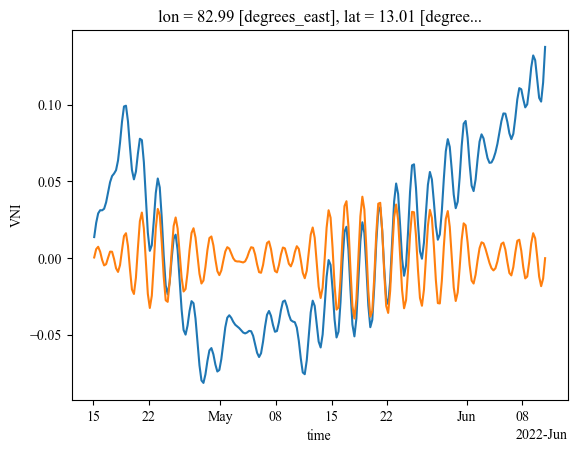

In [23]:
lp_merge.VNI.sel(lat=13,method='nearest').sel(depth=slice(50,100)).mean('depth').plot()
bp_merge.VNI.sel(lat=13,method='nearest').sel(depth=slice(50,100)).mean('depth').plot()
a=lp_merge.VNI.sel(lat=13,method='nearest').sel(depth=slice(50,100)).mean('depth')
b=bp_merge.VNI.sel(lat=13,method='nearest').sel(depth=slice(50,100)).mean('depth')

(0.0, 2.5)

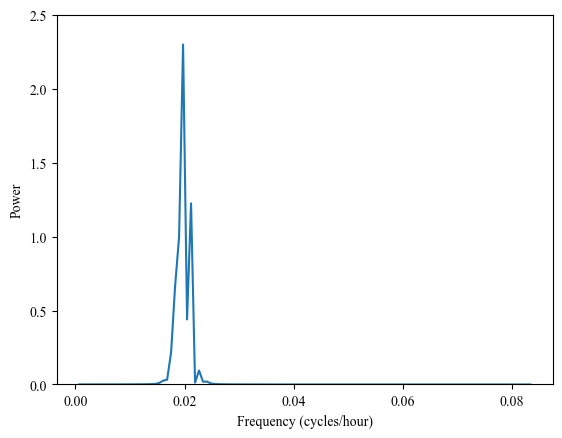

In [67]:
import numpy as np
import matplotlib.pyplot as plt

dt = 6

a = b - np.mean(b)

A = np.fft.rfft(a)
freq = np.fft.rfftfreq(len(a), d=dt)
power = np.abs(A)**2

plt.figure()
plt.plot(freq[1:], power[1:])
plt.xlabel('Frequency (cycles/hour)')
plt.ylabel('Power')
plt.ylim(0,2.5)
plt.axhline()

(0.0, 2.5)

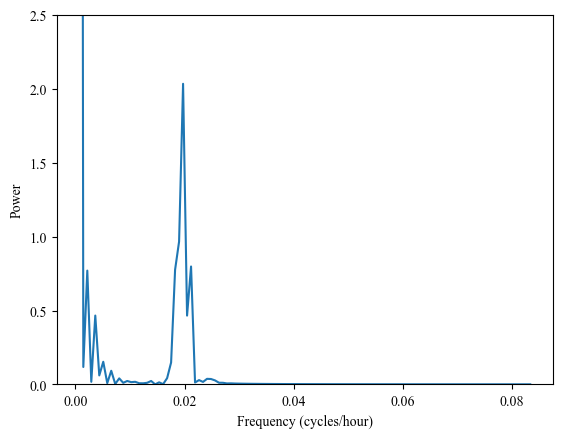

In [66]:
import numpy as np
import matplotlib.pyplot as plt

dt = 6

a = a - np.mean(a)

A = np.fft.rfft(a)
freq = np.fft.rfftfreq(len(a), d=dt)
power = np.abs(A)**2

plt.figure()
plt.plot(freq[1:], power[1:])
plt.xlabel('Frequency (cycles/hour)')
plt.ylabel('Power')
plt.ylim(0,2.5)

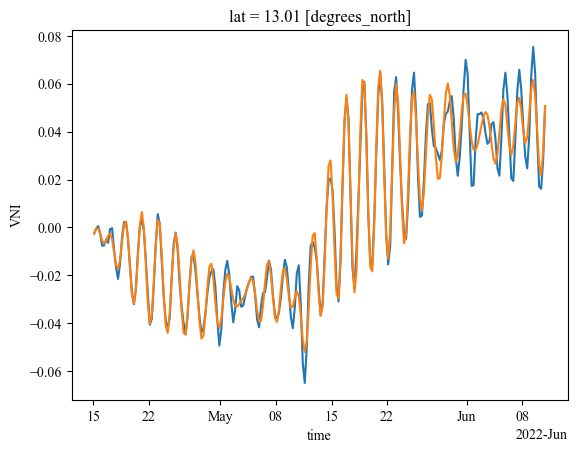

In [47]:
dsv.sel(lat=13,method='nearest').sel(depth=slice(50,100)).mean('depth').plot()
(a+b).plot()

In [26]:
EKE=0.5*1024*(bp_merge.UNI**2)+(bp_merge.VNI**2)

In [27]:
EKE_asani=EKE.sel(time=slice('06-may-2022','25-may-2022')).mean('time')

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Create output folder
os.makedirs('figs', exist_ok=True)

# Contour levels
levels = np.logspace(-5, 0.1, 20)

# Loop over all timesteps
for k in range(len(EKE.time)):

    fig, ax = plt.subplots(figsize=(12,7))

    pl1 = ax.contourf(
        EKE.lat,
        EKE.depth,
        EKE.isel(time=k).T.data,
        levels=levels,
        norm=LogNorm(),
        extend='both',
        cmap='jet'
    )

    cbar = fig.colorbar(
        pl1,
        ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1]
    )

    ax.invert_yaxis()
    ax.set_ylim(400, 50)

    ax.set_title(str(EKE.isel(time=k).time.data))

    # Save as 000.jpg, 001.jpg, ...
    fig.savefig(
        f'figs/{k:03d}.jpg',
        dpi=300,
        bbox_inches='tight'
    )

    plt.close(fig)

    print(f'Saved figs/{k:03d}.jpg')

In [8]:
ds=ren_fun_sck('rho.nc').sel(time=slice('06-may-2022','25-may-2022')).mean('time')
rho0=ds.RHO
rho_zgrad=rho0.differentiate('depth')

g = 9.81          # m s^-2
rho0 = 1025.0     # reference density

N2 = (g / rho0) * rho_zgrad
ds_vort=ren_fun_sck('asani_83.nc').VORT
VV=ren_fun_sck('asani_83.nc').UAVE

In [19]:
N2_sec=N2
zeta_sec=ds_vort.sel(time=slice('06-may-2022','25-may-2022')).mean('time')
vvel_sec=VV.sel(time=slice('06-may-2022','25-may-2022')).mean('time')

In [9]:
N2=import numpy as np

Omega = 7.2921e-5   # Earth's rotation rate (rad/s)

def coriolis(lat):
    return 2 * Omega * np.sin(np.deg2rad(lat))


def trace_ray(lat0, z0, omega, depth, N2_profile,
              dlat=-0.01, nsteps=5000):

    lat_ray = [lat0]
    z_ray = [z0]

    for _ in range(nsteps):

        lat_now = lat_ray[-1]
        z_now = z_ray[-1]

        # stop if outside depth range
        if z_now < depth.min() or z_now > depth.max():
            break

        # local N²
        N2_local = np.interp(z_now, depth, N2_profile)

        f = coriolis(lat_now)

        # propagation condition
        if omega <= abs(f):
            break

        if omega**2 >= N2_local:
            break

        slope = -111.2e3 * np.sqrt(
            (omega**2 - f**2) /
            (N2_local - omega**2)
        )

        lat_new = lat_now + dlat
        z_new = z_now + slope * dlat

        lat_ray.append(lat_new)
        z_ray.append(z_new)

    return np.array(lat_ray), np.array(z_ray)

In [10]:
lat0 = 13.0
z0   = 60.0
f0 = coriolis(lat0)
omega = 1.1 * f0

lat_ray, z_ray = trace_ray(
    lat0,
    z0,
    omega,
    N2.sel(lat=lat0,method='nearest').dropna('depth').depth,
    N2.sel(lat=lat0,method='nearest').dropna('depth')
)

(400.0, 50.0)

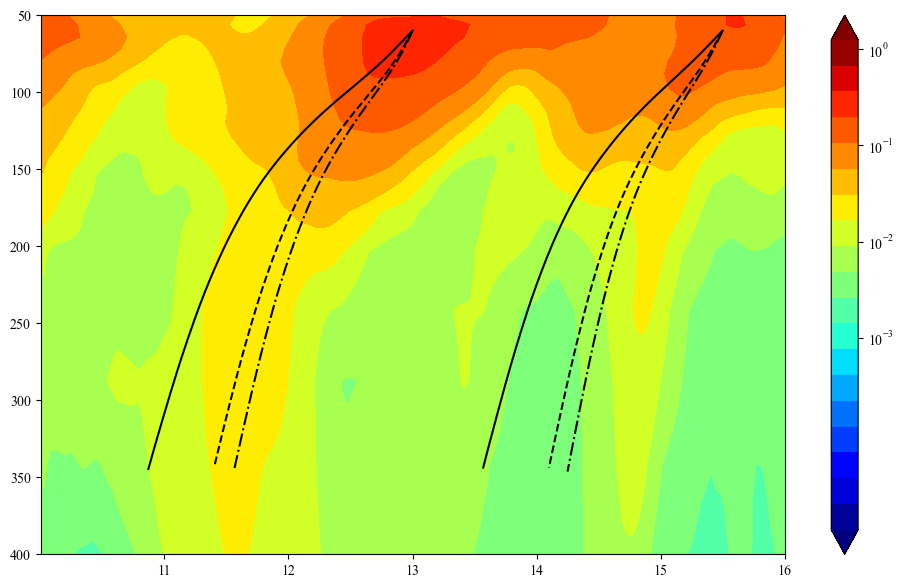

In [227]:
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(12,7))
levels = np.logspace(-5, 0.1, 20)
pl1 = ax.contourf(
        EKE_asani.lat,
        EKE_asani.depth,
        EKE_asani.T.data,
        levels=levels,
        norm=LogNorm(),
        extend='both',
        cmap='jet'
    )

cbar = fig.colorbar(pl1,ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1])
lat0 = 13.0
z0   = 60.0
f0 = coriolis(lat0)

omega = 1.05 * f0
lat_ray, z_ray = trace_ray(lat0,z0,omega,N2.sel(lat=lat0,method='nearest').dropna('depth').depth,N2.sel(lat=lat0,method='nearest').dropna('depth'))
plt.plot(lat_ray,z_ray,color='black')

omega = 1.15 * f0
lat_ray, z_ray = trace_ray(lat0,z0,omega,N2.sel(lat=lat0,method='nearest').dropna('depth').depth,N2.sel(lat=lat0,method='nearest').dropna('depth'))
plt.plot(lat_ray,z_ray,color='black',ls='--')

omega = 1.2 * f0
lat_ray, z_ray = trace_ray(lat0,z0,omega,N2.sel(lat=lat0,method='nearest').dropna('depth').depth,N2.sel(lat=lat0,method='nearest').dropna('depth'))
plt.plot(lat_ray,z_ray,color='black',ls='-.')


lat0 = 15.5
z0   = 60.0
f0 = coriolis(lat0)

omega = 1.05 * f0
lat_ray, z_ray = trace_ray(lat0,z0,omega,N2.sel(lat=lat0,method='nearest').dropna('depth').depth,N2.sel(lat=lat0,method='nearest').dropna('depth'))
plt.plot(lat_ray,z_ray,color='black')

omega = 1.15 * f0
lat_ray, z_ray = trace_ray(lat0,z0,omega,N2.sel(lat=lat0,method='nearest').dropna('depth').depth,N2.sel(lat=lat0,method='nearest').dropna('depth'))
plt.plot(lat_ray,z_ray,color='black',ls='--')

omega = 1.2 * f0
lat_ray, z_ray = trace_ray(lat0,z0,omega,N2.sel(lat=lat0,method='nearest').dropna('depth').depth,N2.sel(lat=lat0,method='nearest').dropna('depth'))
plt.plot(lat_ray,z_ray,color='black',ls='-.')

ax.invert_yaxis()
ax.set_ylim(400, 50)

In [11]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

Omega = 7.2921e-5

def coriolis(lat):
    return 2 * Omega * np.sin(np.deg2rad(lat))


def trace_ray_feff(lat0, z0, omega,
                   lat, depth,
                   N2_sec,
                   zeta_sec,
                   dlat=-0.01,
                   nsteps=5000):

    lat = np.asarray(lat)
    depth = np.asarray(depth)
    N2_sec = np.asarray(N2_sec)
    zeta_sec = np.asarray(zeta_sec)

    # Interpolators
    N2_interp = RegularGridInterpolator(
        (lat, depth),
        N2_sec,
        bounds_error=False,
        fill_value=np.nan
    )

    zeta_interp = RegularGridInterpolator(
        (lat, depth),
        zeta_sec,
        bounds_error=False,
        fill_value=np.nan
    )

    lat_ray = [lat0]
    z_ray = [z0]

    lat_min, lat_max = lat.min(), lat.max()
    z_min, z_max = depth.min(), depth.max()

    for i in range(nsteps):

        lat_now = lat_ray[-1]
        z_now = z_ray[-1]


        # ---- domain checks ----
        if lat_now < lat_min or lat_now > lat_max:

            break

        if z_now < z_min or z_now > z_max:

            break

        # ---- interpolate ----
        N2_local = N2_interp((lat_now, z_now))
        zeta_local = zeta_interp((lat_now, z_now))

        if np.isnan(N2_local):

            break

        if np.isnan(zeta_local):

            break

        N2_local = float(N2_local)
        zeta_local = float(zeta_local)

        # ---- effective Coriolis ----
        f_eff = coriolis(lat_now) + 0.5 * zeta_local


        # ---- propagation conditions ----
        if omega <= np.abs(f_eff):

            break

        if omega**2 >= N2_local:

            break

        # ---- ray slope ----
        denom = (N2_local - omega**2)
        numer = (omega**2 - f_eff**2)

        if denom <= 0 or numer <= 0:
            break

        dz_dlat = -111.2e3 * np.sqrt(numer / denom)

        # ---- step update ----
        lat_new = lat_now + dlat
        z_new = z_now + dz_dlat * dlat

        lat_ray.append(lat_new)
        z_ray.append(z_new)

    return np.array(lat_ray), np.array(z_ray)

(400.0, 50.0)

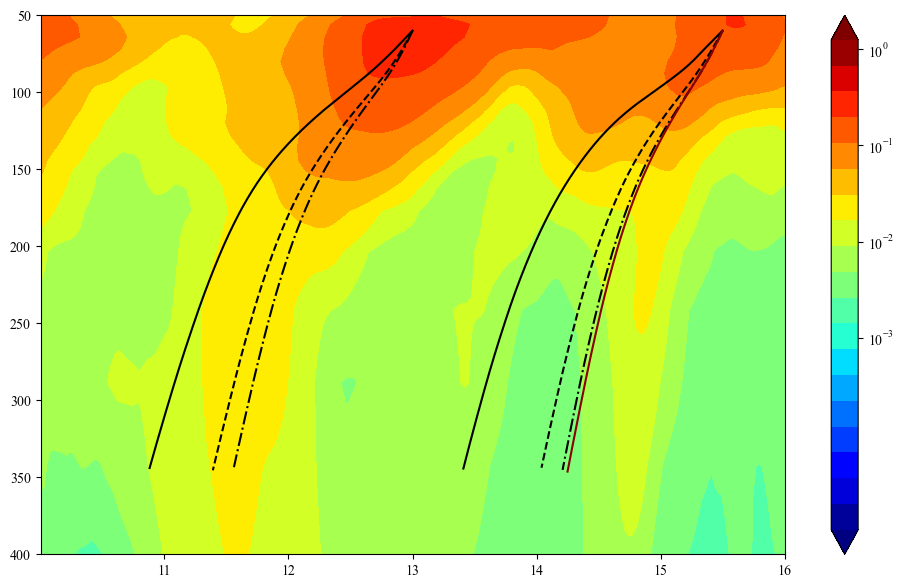

In [12]:
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(12,7))
levels = np.logspace(-5, 0.1, 20)
pl1 = ax.contourf(
        EKE_asani.lat,
        EKE_asani.depth,
        EKE_asani.T.data,
        levels=levels,
        norm=LogNorm(),
        extend='both',
        cmap='jet'
    )

cbar = fig.colorbar(pl1,ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1])

lat = N2.lat.values
depth = N2.depth.values
N2_sec = np.asarray(N2_sec).T
zeta_sec = np.asarray(zeta_sec).T 

lat0 = 13.0
z0   = 60.0
f0 = coriolis(lat0)

omega = 1.05 * f0
lat_ray, z_ray = trace_ray_feff(lat0,z0,omega,lat,depth,N2_sec,zeta_sec)
plt.plot(lat_ray,z_ray,color='black')




omega = 1.15 * f0
lat_ray, z_ray = trace_ray_feff(lat0,z0,omega,lat,depth,N2_sec,zeta_sec)
plt.plot(lat_ray,z_ray,color='black',ls='--')

omega = 1.2 * f0
lat_ray, z_ray = trace_ray_feff(lat0,z0,omega,lat,depth,N2_sec,zeta_sec)
plt.plot(lat_ray,z_ray,color='black',ls='-.')



lat0 = 15.5
z0   = 60.0
f0 = coriolis(lat0)

omega = 1.05 * f0
lat_ray, z_ray = trace_ray_feff(lat0,z0,omega,lat,depth,N2_sec,zeta_sec)
plt.plot(lat_ray,z_ray,color='black')


omega = 1.15 * f0
lat_ray, z_ray = trace_ray_feff(lat0,z0,omega,lat,depth,N2_sec,zeta_sec)
plt.plot(lat_ray,z_ray,color='black',ls='--')

omega = 1.2 * f0
lat_ray, z_ray = trace_ray_feff(lat0,z0,omega,lat,depth,N2_sec,zeta_sec)
plt.plot(lat_ray,z_ray,color='black',ls='-.')


omega = 1.2 * f0
lat_ray1, z_ray1 = trace_ray(lat0,z0,omega,N2.sel(lat=lat0,method='nearest').depth.values,N2.sel(lat=lat0,method='nearest').values)
plt.plot(lat_ray1,z_ray1,color='darkred')
ax.invert_yaxis()
ax.set_ylim(400, 50)

(400.0, 50.0)

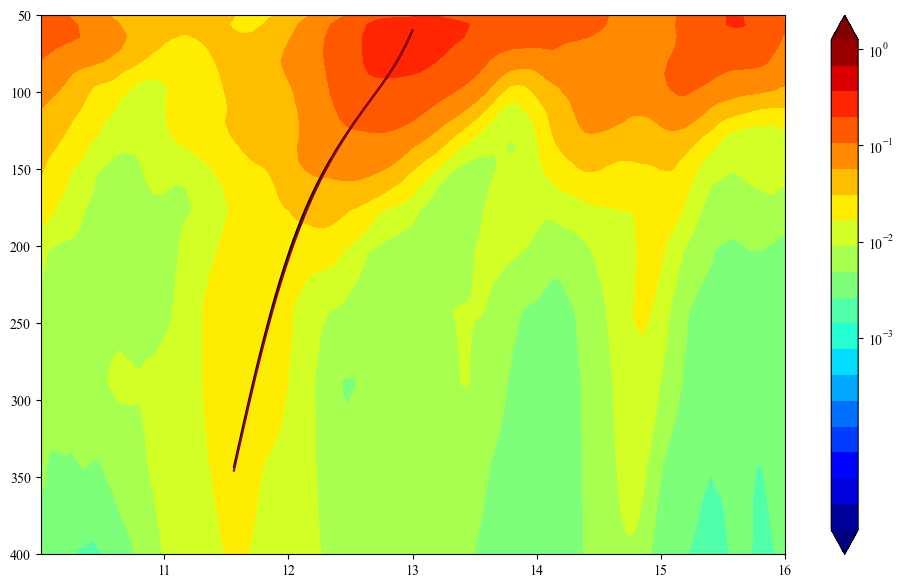

In [13]:
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(12,7))
levels = np.logspace(-5, 0.1, 20)
pl1 = ax.contourf(
        EKE_asani.lat,
        EKE_asani.depth,
        EKE_asani.T.data,
        levels=levels,
        norm=LogNorm(),
        extend='both',
        cmap='jet'
    )

cbar = fig.colorbar(pl1,ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1])


lat0 = 13
z0   = 60.0
f0 = coriolis(lat0)


omega = 1.2 * f0
lat_ray, z_ray = trace_ray_feff(lat0,z0,omega,lat,depth,N2_sec,zeta_sec)
plt.plot(lat_ray,z_ray,color='black',ls='-')


omega = 1.2 * f0
lat_ray1, z_ray1 = trace_ray(lat0,z0,omega,N2.sel(lat=lat0,method='nearest').depth.values,N2.sel(lat=lat0,method='nearest').values)
plt.plot(lat_ray1,z_ray1,color='darkred')

ax.invert_yaxis()
ax.set_ylim(400, 50)

## hamiltonian

In [9]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

Omega = 7.2921e-5

def coriolis(lat):
    return 2 * Omega * np.sin(np.deg2rad(lat))


def trace_ray_feff_doppler(
        lat0, z0,
        omega_obs,          # observed frequency
        wavelength_h,       # horizontal wavelength (m)
        lat, depth,
        N2_sec,
        zeta_sec,
        V_sec,              # background velocity along section (m/s)
        dlat=-0.01,
        nsteps=5000):

    lat = np.asarray(lat)
    depth = np.asarray(depth)

    N2_sec = np.asarray(N2_sec)
    zeta_sec = np.asarray(zeta_sec)
    V_sec = np.asarray(V_sec)

    # horizontal wavenumber
    l = 2*np.pi / wavelength_h

    N2_interp = RegularGridInterpolator(
        (lat, depth),
        N2_sec,
        bounds_error=False,
        fill_value=np.nan
    )

    zeta_interp = RegularGridInterpolator(
        (lat, depth),
        zeta_sec,
        bounds_error=False,
        fill_value=np.nan
    )

    V_interp = RegularGridInterpolator(
        (lat, depth),
        V_sec,
        bounds_error=False,
        fill_value=np.nan
    )

    lat_ray = [lat0]
    z_ray = [z0]

    for _ in range(nsteps):

        lat_now = lat_ray[-1]
        z_now = z_ray[-1]

        if lat_now < lat.min() or lat_now > lat.max():
            break

        if z_now < depth.min() or z_now > depth.max():
            break

        N2_local = float(N2_interp((lat_now, z_now)))
        zeta_local = float(zeta_interp((lat_now, z_now)))
        V_local = float(V_interp((lat_now, z_now)))

        if np.isnan(N2_local):
            break

        if np.isnan(zeta_local):
            break

        if np.isnan(V_local):
            break

        f_eff = coriolis(lat_now) + 0.5*zeta_local

        # Doppler-corrected intrinsic frequency
        omega_int = omega_obs - l*V_local

        if omega_int <= np.abs(f_eff):
            break

        if omega_int**2 >= N2_local:
            break

        numer = omega_int**2 - f_eff**2
        denom = N2_local - omega_int**2

        if numer <= 0 or denom <= 0:
            break

        dz_dlat = -111.2e3 * np.sqrt(numer / denom)

        lat_new = lat_now + dlat
        z_new = z_now + dz_dlat*dlat

        lat_ray.append(lat_new)
        z_ray.append(z_new)

    return np.array(lat_ray), np.array(z_ray)

In [11]:
N2_sec=N2
zeta_sec=ds_vort.sel(time=slice('06-may-2022','25-may-2022')).mean('time')
vvel_sec=VV.sel(time=slice('06-may-2022','25-may-2022')).mean('time')

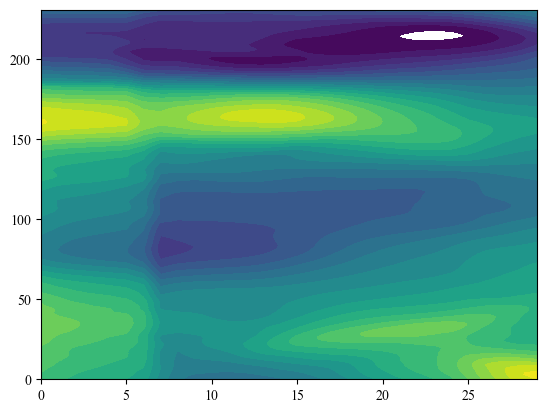

In [40]:
plt.contourf(V_secn,levels=np.arange(-1,1.1,0.1)/5)

In [41]:
Lh = 100e3   # metres
lat = N2.lat.values
depth = N2.depth.values
N2_secn = np.asarray(N2_sec.squeeze()).T
zeta_secn = np.asarray(zeta_sec.squeeze()).T 
V_secn=np.asarray(vvel_sec.squeeze()).T
f0=coriolis(13)

lat_ray2, z_ray2 = trace_ray_feff_doppler(
    lat0=13,
    z0=60,
    omega_obs=1.2*f0,
    wavelength_h=Lh,
    lat=lat,
    depth=depth,
    N2_sec=N2_secn,
    zeta_sec=zeta_secn,
    V_sec=V_secn
)

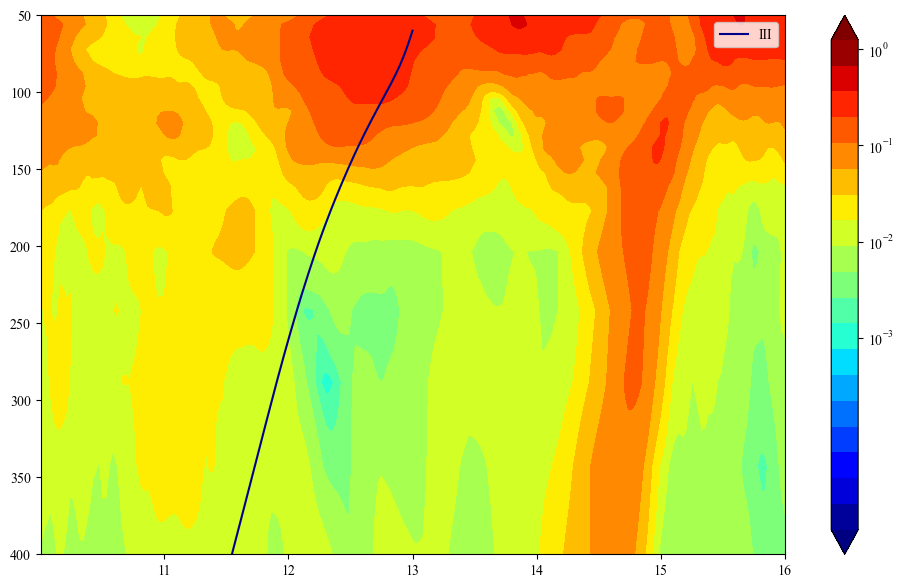

In [31]:
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(12,7))
levels = np.logspace(-5, 0.1, 20)
pl1 = ax.contourf(
        EKE_asani.lat,
        EKE_asani.depth,
        EKE_asani.squeeze().T.data,
        levels=levels,
        norm=LogNorm(),
        extend='both',
        cmap='jet'
    )

cbar = fig.colorbar(pl1,ticks=[1e-3, 1e-2, 1e-1, 1e0, 1e1])


lat0 = 13
z0   = 60.0
f0 = coriolis(lat0)



omega = 1.2 * f0

plt.plot(lat_ray2,z_ray2,color='darkblue',label='III')
ax.invert_yaxis()
ax.set_ylim(400, 50)
plt.legend()